# Keypoint Classifier Training
This notebook mirrors the original keypoint classification workflow.

In [24]:
import csv
from pathlib import Path

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, regularizers


In [25]:
RANDOM_SEED = 42
NUM_CLASSES = 10
DATASET_PATH = Path(r'/content/keypoint_10gestures.csv')
MODEL_SAVE_PATH = Path('../models/keypoint/keypoint_classifier_cnn.keras')
TFLITE_SAVE_PATH = Path('../models/keypoint/keypoint_classifier_cnn.tflite')

In [26]:
X_dataset = np.loadtxt(DATASET_PATH, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))
y_dataset = np.loadtxt(DATASET_PATH, delimiter=',', dtype='int32', usecols=(0,))

X_train, X_test, y_train, y_test = train_test_split(
    X_dataset, y_dataset,
    train_size=0.75,
    random_state=RANDOM_SEED,
    stratify=y_dataset  # 关键：按类别分层，避免数据偏移
)

In [27]:
# ===========================================
# 2. 关键点归一化（强烈推荐）
# ===========================================
def normalize_keypoints(X):
    X = X.copy().astype(np.float32)

    # wrist 位置（第 0 点的 x, y）
    wrist_x = X[:, 0]
    wrist_y = X[:, 1]

    # 平移：所有 keypoint 减去 wrist 坐标
    X[:, 0:42:2] -= wrist_x[:, None]
    X[:, 1:42:2] -= wrist_y[:, None]

    # 缩放：按每个样本独立最大值进行归一化
    scale = np.max(np.abs(X), axis=1, keepdims=True)
    scale[scale == 0] = 1e-6
    X = X / scale

    return X
X_train = normalize_keypoints(X_train)
X_test = normalize_keypoints(X_test)

In [28]:
# ===========================================
# 3. 数据增强（关键点 jitter）
# ===========================================
def augment(X):
    noise = np.random.normal(0, 0.01, X.shape).astype(np.float32)
    return X + noise

# # 数据增强 + reshape
# X_train_aug = augment(X_train)

# 数据增强 + reshape
X_train_aug = augment(X_train).reshape(-1, 21, 2)
X_test = X_test.reshape(-1, 21, 2)

In [29]:
# ===========================================
# 4. Optimizer：AdamW + Cosine LR
# ===========================================
lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=3e-4,
    first_decay_steps=2000,
)

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=1e-4
)

In [30]:
# ===========================================
# 5. 模型结构（验证稳定、效果最佳 MLP）0.66
# ===========================================
model0 = tf.keras.Sequential([
    layers.Input((42,)),

    layers.Dense(256, activation='gelu',
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(256, activation='gelu',
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='gelu',
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.25),

    layers.Dense(64, activation='gelu',
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(NUM_CLASSES, activation='softmax')
])

# 5. 构建 1D-CNN 模型
# ==============================
model = tf.keras.Sequential([
    layers.Input(shape=(21, 2)),

    layers.Conv1D(64, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv1D(128, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.3),

    layers.Conv1D(128, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv1D(256, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling1D(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.25),

    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
# ===========================================
# 6. EarlyStopping（避免震荡）
# ===========================================
early_stop_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True
)

In [32]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(str(MODEL_SAVE_PATH), save_best_only=True)

In [33]:

history = model.fit(
    X_train_aug, y_train,
    validation_data=(X_test, y_test),
    epochs=300,
    batch_size=128,
    callbacks=[checkpoint_cb,early_stop_cb],  # ✅ 在这里传入
    verbose=1
)

Epoch 1/300
169/169 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.3810 - loss: 1.9888 - val_accuracy: 0.1007 - val_loss: 4.0072
Epoch 2/300
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7176 - loss: 0.8766 - val_accuracy: 0.1654 - val_loss: 4.2348
Epoch 3/300
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7966 - loss: 0.6515 - val_accuracy: 0.6929 - val_loss: 0.9322
Epoch 4/300
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8539 - loss: 0.4804 - val_accuracy: 0.9278 - val_loss: 0.2508
Epoch 5/300
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8885 - loss: 0.3706 - val_accuracy: 0.9502 - val_loss: 0.1780
Epoch 6/300
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8974 - loss: 0.3338 - val_accuracy: 0.9594 - val_loss: 0.1546
Epoch 7/300
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9150 - loss: 0.2987 - val_accuracy: 0.9589 - val_loss: 0.1487
Epoch 8/300
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9232 - loss: 0.2660 - val_ac

In [34]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
converter._experimental_lower_tensor_list_ops = False
tflite_quantized_model = converter.convert()
TFLITE_SAVE_PATH.write_bytes(tflite_quantized_model)

Saved artifact at '/tmp/tmpvjobnupe'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 21, 2), dtype=tf.float32, name='keras_tensor_76')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  138132324255888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138132324266064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138132324266448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138132324267408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138132324267216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138132324266640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138132324267024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138132324266256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138132324265488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138132324268560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138132324268368:

233704

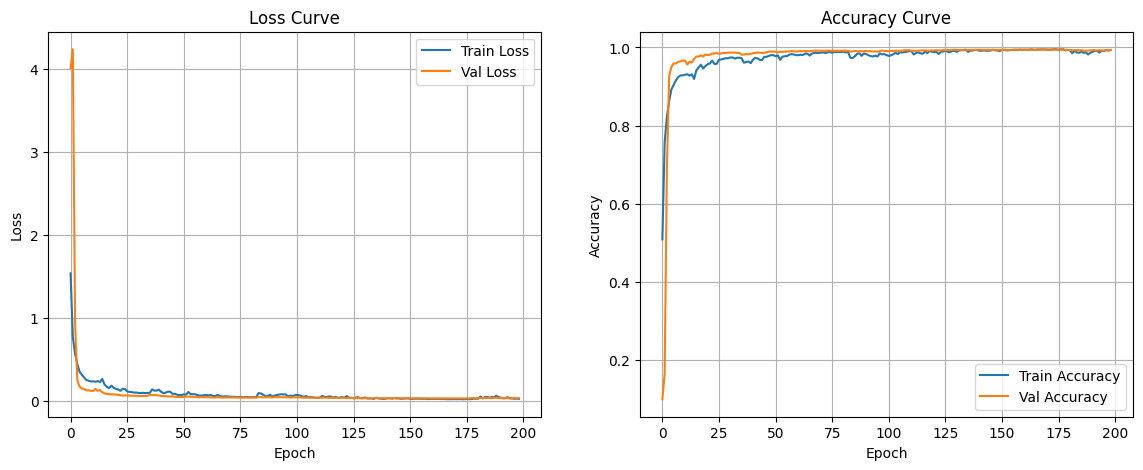


📌 Test Loss: 0.0358
📌 Test Accuracy: 0.9941
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


<Figure size 600x600 with 0 Axes>

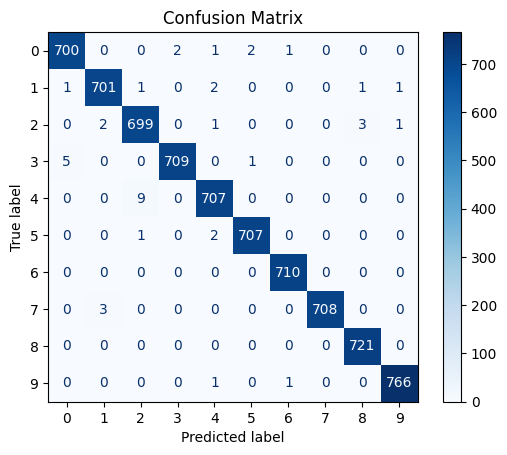


📌 Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       706
           1       0.99      0.99      0.99       707
           2       0.98      0.99      0.99       706
           3       1.00      0.99      0.99       715
           4       0.99      0.99      0.99       716
           5       1.00      1.00      1.00       710
           6       1.00      1.00      1.00       710
           7       1.00      1.00      1.00       711
           8       0.99      1.00      1.00       721
           9       1.00      1.00      1.00       768

    accuracy                           0.99      7170
   macro avg       0.99      0.99      0.99      7170
weighted avg       0.99      0.99      0.99      7170



In [35]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# =============================
# 1. 绘制 Loss 和 Accuracy 曲线
# =============================

plt.figure(figsize=(14, 5))

# ---- Loss ----
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# ---- Accuracy ----
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Val Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()


# =============================
# 2. 打印 Test Set 评估指标
# =============================

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n📌 Test Loss: {test_loss:.4f}")
print(f"📌 Test Accuracy: {test_acc:.4f}")


# =============================
# 3. 混淆矩阵 + 可视化
# =============================

y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix")
plt.show()

# =============================
# 4. 精确率/召回率/F1
# =============================
print("\n📌 Classification Report:")
print(classification_report(y_test, y_pred))
